In [2]:
# Step: Import required libraries and dependencies

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from keras.applications.vgg16 import VGG16
from tensorflow.keras.datasets import cifar10 as cf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.utils import to_categorical


c:\Users\Workstation\Python Environments\mlenv\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [3]:
# Step: Load dataset into training and test/validation sets

(x_train, y_train), (x_test, y_test) = cf.load_data()

In [5]:
# Step: Inspect data shapes and dimensions

print(x_train.shape)
print(y_train.shape)
print(y_test.shape)
print(y_test.shape)


(50000, 32, 32, 3)
(50000, 1)
(10000, 1)
(10000, 1)


In [6]:
# Step: Normalize pixel values to the [0, 1] range

x_train = x_train/255.0
x_test = x_test/255.0

In [7]:
# Step: Convert labels to one-hot encoded vectors

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [8]:
# Step: Initialize pretrained transfer learning backbone

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

In [9]:
# freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

In [10]:
# Build the model
model = Sequential()

#define the input shape
model.add(InputLayer(input_shape=(32, 32, 3))) # add this line for new image data

# Add the VGG16 base model
model.add(base_model)

#Flatten / Pool the output from VGG16's convolutional layers
# model.add(Flatten()) # this is the original method
model.add(GlobalAveragePooling2D())

#Add a fully connected layer with 256 units and ReLU activation
model.add(Dense(256, activation='relu'))

#Add a dropout layer with a dropout rate of 0.5 for regularization
model.add(Dropout(0.5))

# Add output layer with 10 units (for 10 classes) and softmax activation
model.add(Dense(10, activation='softmax'))

#Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

#print the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 14848586 (56.64 MB)
Trainable params: 133898 (523.04 KB)
Non-trainable params: 14714688 (56.13 MB)
_________

In [11]:
# Create data augmentation generator, to reduce overfitting
datagen = ImageDataGenerator(
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)

In [12]:
# Fit the model using data augmentation
batch_size = 64
epochs = 3
train_generator = datagen.flow(x_train, y_train, batch_size = batch_size)

In [13]:
# Step: Inspect data shapes and dimensions

x_train.shape[0]

50000

In [14]:
# Step: Inspect data shapes and dimensions

history = model.fit(train_generator,steps_per_epoch = x_train.shape[0] // batch_size,
                    epochs = epochs,
                    validation_data = (x_test, y_test),
                    verbose = 1)

Epoch 1/3


781/781 [==============================] - 110s 138ms/step - loss: 1.5788 - accuracy: 0.4435 - val_loss: 1.3257 - val_accuracy: 0.5291
Epoch 2/3
781/781 [==============================] - 109s 140ms/step - loss: 1.3886 - accuracy: 0.5125 - val_loss: 1.2531 - val_accuracy: 0.5588
Epoch 3/3
781/781 [==============================] - 117s 150ms/step - loss: 1.3302 - accuracy: 0.5326 - val_loss: 1.2192 - val_accuracy: 0.5667


In [15]:
# Step: Evaluate model performance on unseen data

test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 1)
print('Test accuracy:', test_acc)

313/313 [==============================] - 21s 67ms/step - loss: 1.2192 - accuracy: 0.5667
Test accuracy: 0.5666999816894531


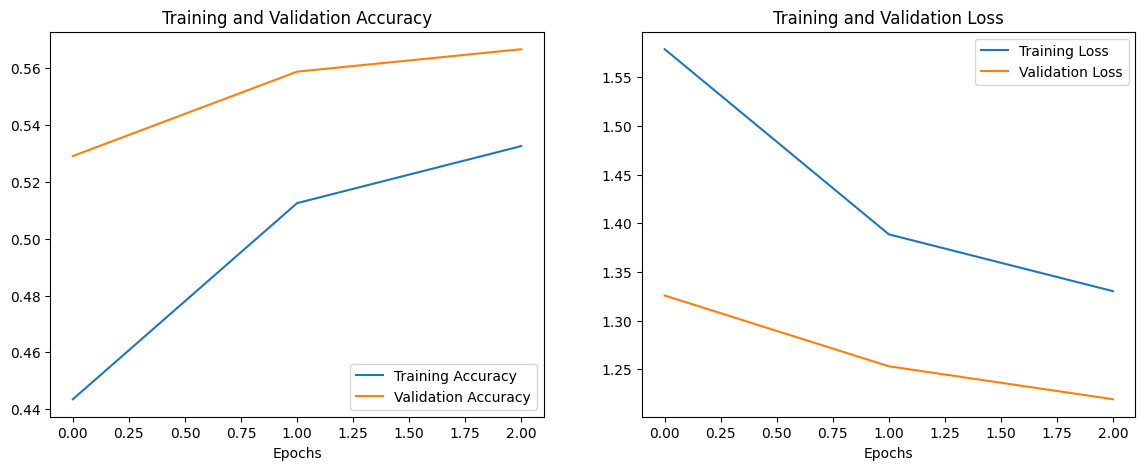

In [16]:
# plotting the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.legend(loc = 'lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()
